# Import Required Modules

In [10]:
import plotly.express as px
from sklearn.decomposition import PCA
import scipy.io as sio
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Load Data from matfile 

In [3]:
phase2_data = sio.loadmat('../data/phase2_data_20220215.mat')
print(phase2_data.keys())
print(phase2_data["Fs"])

dict_keys(['__header__', '__version__', '__globals__', 'Fs', 'mine', 'note', 'wavdir', 'x', 'y', 'SNR'])
[[48000]]


# Prepare Pandas Dataframe

In [4]:

df_x  = pd.DataFrame(phase2_data["x"].T)
df_y  = pd.DataFrame(phase2_data["y"].T, columns=["y"])
# df_mine = pd.DataFrame(phase2_data["mine"].T, columns=["mine"])

df = pd.concat([df_x, df_y], axis=1, join="inner")

df = df.dropna()

display(df)

,0,1,2,3,4,5,6,7,8,9,...,4791,4792,4793,4794,4795,4796,4797,4798,4799,y
0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000031,0.000000,0.000031,0.000000,-0.000061,0.000000,0.0
1,-0.000061,-0.000031,-0.000092,-0.000031,-0.000061,-0.000061,-0.000061,-0.000061,-0.000031,-0.000061,...,-0.000031,0.000031,-0.000061,0.000000,0.000031,0.000122,0.000031,0.000092,0.000092,0.0
2,0.000000,-0.000122,0.000000,-0.000061,-0.000031,-0.000031,0.000000,-0.000031,0.000031,-0.000061,...,0.000183,0.000244,0.000031,0.000061,0.000092,0.000000,0.000031,-0.000153,-0.000122,0.0
3,0.000061,-0.000031,0.000000,0.000000,0.000000,0.000000,-0.000031,0.000000,0.000000,-0.000031,...,0.000122,0.000153,0.000153,0.000214,0.000183,0.000244,0.000244,0.000305,0.000275,0.0
4,0.000000,0.000031,-0.000061,0.000061,0.000000,0.000000,0.000031,-0.000031,-0.000031,0.000000,...,0.000244,0.000275,0.000214,0.000366,0.000275,0.000397,0.000244,0.000458,0.000366,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.036957,0.042694,0.047516,0.050690,0.052979,0.053772,0.053741,0.054047,0.054321,1.0
9919,0.000031,0.000000,-0.000061,-0.000031,-0.000061,0.000092,0.000031,0.000122,0.000153,0.000183,...,-0.015991,-0.017029,-0.017975,-0.018951,-0.020050,-0.020691,-0.021271,-0.021759,-0.021851,1.0
9920,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.025238,-0.031494,-0.038025,-0.046021,-0.053101,-0.060120,-0.068390,-0.076202,-0.082703,1.0
9921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.022125,-0.022217,-0.022217,-0.022186,-0.021851,-0.021332,-0.020721,-0.019806,-0.018616,1.0


# Seperate features from the Dataframe
## Standardize data 
Mean = 0, Variance = 1
## PCA Analysis
1. 2 Component analysis
1. 3D Scatter plot giving z=-1 for label=0 and z=1 for label=1

In [5]:
X = df.iloc[:, :-1]

scaler = StandardScaler()
scaler.fit(X)
X = scaler.transform(X)

pca = PCA(n_components=2)

components = pca.fit_transform(X)

new_axis = phase2_data["y"].T.copy()
new_axis[new_axis == 0] = -1

df_components = pd.DataFrame(components, columns=["PC1", "PC2"])
df_new_axis = pd.DataFrame( new_axis, columns=["z"])

df_kernel = pd.concat([df_components, df_new_axis], axis=1, join="inner")

one_count = np.sum(df_kernel["z"] == 1)
print("one_count", one_count)
zero_count = np.sum(df_kernel["z"] == -1)
print("zero_count", zero_count)

fig = px.scatter_3d(df_kernel, x="PC1", y="PC2", z="z", color=df['y'])
fig.show()
fig.write_image("../assets/p2_pca_3d.png")

one_count 3124
zero_count 3856


In [14]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# Displaying how the waveform of both classes looks

0      -0.000061
1       0.000000
2       0.000000
3       0.000031
4      -0.000031
          ...   
4796   -0.000580
4797   -0.000580
4798   -0.000580
4799   -0.000305
y       0.000000
Name: 12, Length: 4801, dtype: float64

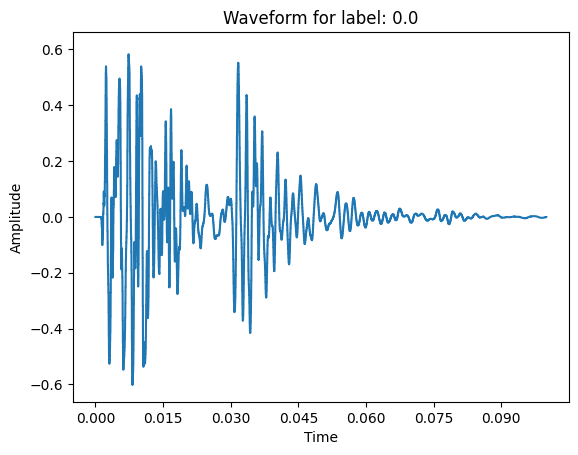

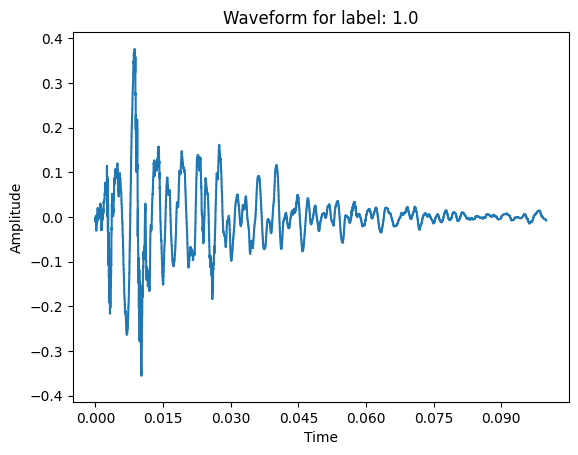

In [7]:
example = df.loc[12]
label = example.values[-1]
sample_rate_phase1 = 48000

display(example)
#Displaying 1st Waveform
example = example[:-1].values
plt.figure()
librosa.display.waveshow(example, sr=sample_rate_phase1)
plt.title('Waveform for label: {}'.format(label))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

example9922 = df.iloc[8439, :-1].values
label9922 = df.iloc[8439, -1]
#Displaying 2nd Waveform
plt.figure()
librosa.display.waveshow(example9922, sr=sample_rate_phase1)
plt.title('Waveform for label: {}'.format(label9922))
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()


# PCA analysis
1. Analysing how many components capture different amounts of variance in the features
1. Variance vs Number of Components Plot
1. Plot the components

cumulative_variance: [0.04752682 0.08676244 0.11996877 ... 1.         1.         1.        ]


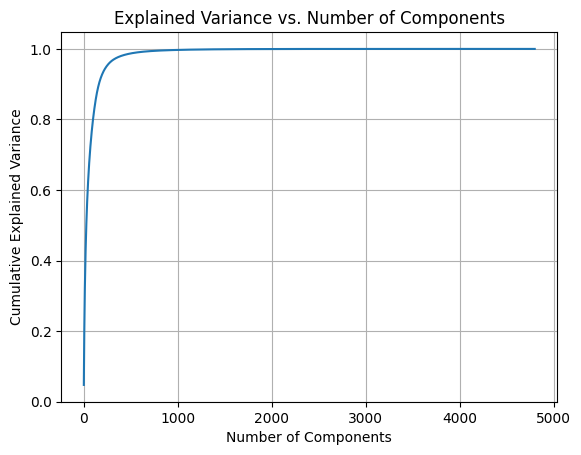

Number of components retaining 95% variance: 242
Number of components retaining 70% variance: 65
Number of components retaining 80% variance: 99


In [8]:
# Assuming X is your data
pca = PCA(n_components=None)
pca.fit(X)

# Calculate cumulative explained variance
cumulative_variance = np.cumsum(pca.explained_variance_ratio_)

print("cumulative_variance:", cumulative_variance)

# Plot cumulative explained variance
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance vs. Number of Components')
plt.grid(True)
plt.show()

# Choose n_components based on the plot or a threshold
n_components = np.argmax(cumulative_variance >= 0.95) + 1
print(f'Number of components retaining 95% variance: {n_components}')

n_components = np.argmax(cumulative_variance >= 0.70) + 1
print(f'Number of components retaining 70% variance: {n_components}')

n_components = np.argmax(cumulative_variance >= 0.80) + 1
print(f'Number of components retaining 80% variance: {n_components}')

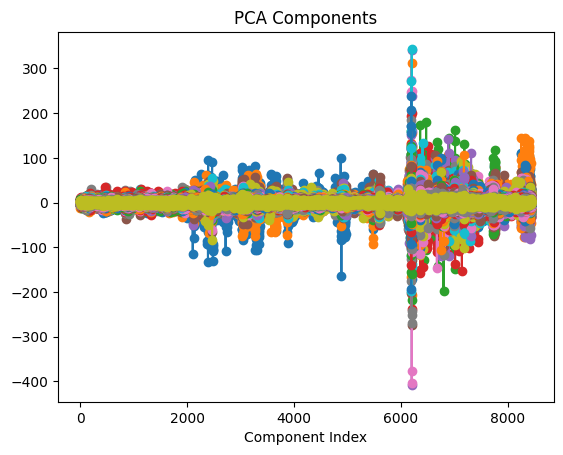

In [9]:
# Apply PCA with the selected number of components
pca_final = PCA(n_components=99)
X_reduced = pca_final.fit_transform(X)

df_pca_plot = pd.DataFrame(X_reduced, columns=[f"PC{i+1}" for i in range(99)])
plt.figure()
plt.plot(df_pca_plot, marker='o', linestyle='-')
plt.title('PCA Components')
plt.xlabel('Component Index')
plt.show()

# Listening to audio

In [10]:
from IPython.display import Audio

print("label", label)
Audio(example, rate=sample_rate_phase1)


label 0.0


In [11]:
display(df.loc[1009])
print(phase2_data["wavdir"][1009])

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
4796   -0.000061
4797   -0.000061
4798   -0.000214
4799   -0.000336
y       0.000000
Name: 1009, Length: 4801, dtype: float64

[(array(['09-36-12_D.wav'], dtype='<U14'), array(['D:\\work\\usask_research\\projects\\automatic_scaling_bar\\phase2_analysis\\recordings\\K3_01_12_2021_raw'],
       dtype='<U98'), array(['04-Jun-2021 00:00:00'], dtype='<U20'), array([[128108]], dtype=int32), array([[0]], dtype=uint8), array([[738311]], dtype=int32))]


# Saving waveforms as pdf seperately for drummy and tight
Some audios are corrupted

In [32]:
pd.set_option('display.max_columns', None)
drummy_df = df[df["y"] == 0]
display(drummy_df)
# from matplotlib.backends.backend_pdf import PdfPages

# with PdfPages('../assets/drummy_waves.pdf') as pdf:

#     for index, row in drummy_df.iterrows():
#         # Create a new figure for each plot
#         plt.figure()
#         librosa.display.waveshow(row[:-1].values, sr=sample_rate_phase1)
#         plt.title('Waveform {} for label: {}'.format(row.name, row.values[-1]))
#         plt.xlabel('Time')
#         plt.ylabel('Amplitude')
#         # Save the current figure to the PDF
#         pdf.savefig()
#         # Close current figure to release memory
#         plt.close()

print(drummy_df.iloc[0])

0         1         2         3         4         5         6  \
0     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1    -0.000061 -0.000031 -0.000092 -0.000031 -0.000061 -0.000061 -0.000061   
2     0.000000 -0.000122  0.000000 -0.000061 -0.000031 -0.000031  0.000000   
3     0.000061 -0.000031  0.000000  0.000000  0.000000  0.000000 -0.000031   
4     0.000000  0.000031 -0.000061  0.000061  0.000000  0.000000  0.000031   
...        ...       ...       ...       ...       ...       ...       ...   
9531 -0.000122 -0.000092 -0.000061 -0.000092 -0.000061 -0.000061 -0.000061   
9532 -0.002075 -0.002228 -0.002289 -0.002441 -0.002533 -0.002777 -0.002777   
9533  0.000031 -0.000061  0.000000 -0.000092 -0.000031 -0.000061 -0.000061   
9534  0.000488  0.000427  0.000488  0.000488  0.000519  0.000458  0.000549   
9535  0.000031  0.000031  0.000031  0.000031  0.000061  0.000000  0.000122   

             7         8         9        10        11        12        13  \
0     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1    -0.000061 -0.000031 -0.000061 -0.000031 -0.000031  0.000031 -0.000061   
2    -0.000031  0.000031 -0.000061  0.000031 -0.000061  0.000031 -0.000031   
3     0.000000  0.000000 -0.000031 -0.000031 -0.000031 -0.000061 -0.000031   
4    -0.000031 -0.000031  0.000000  0.000000 -0.000031 -0.000031  0.000031   
...        ...       ...       ...       ...       ...       ...       ...   
9531 -0.000061 -0.000122 -0.000031 -0.000092 -0.000061 -0.000061 -0.000061   
9532 -0.002838 -0.002838 -0.002960 -0.003082 -0.003174 -0.003174 -0.003174   
9533 -0.000031 -0.000061  0.000000 -0.000031 -0.000061 -0.000031 -0.000031   
9534  0.000488  0.000519  0.000458  0.000488  0.000427  0.000488  0.000427   
9535  0.000000  0.000061  0.000061  0.000031  0.000061  0.000092  0.000031   

            14        15        16        17        18        19        20  \
0     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1     0.000000  0.000061 -0.000031  0.000031  0.000031  0.000000  0.000031   
2     0.000000 -0.000031  0.000000 -0.000061 -0.000031  0.000000 -0.000061   
3    -0.000061  0.000000 -0.000061 -0.000031 -0.000031 -0.000061 -0.000031   
4    -0.000061  0.000000 -0.000061  0.000000  0.000000 -0.000031  0.000000   
...        ...       ...       ...       ...       ...       ...       ...   
9531 -0.000061 -0.000031  0.000000 -0.000031  0.000061  0.000000  0.000000   
9532 -0.002960 -0.002838 -0.002777 -0.002686 -0.002625 -0.002441 -0.002289   
9533  0.000031  0.000061  0.000061  0.000092  0.000061  0.000122  0.000092   
9534  0.000458  0.000336  0.000397  0.000366  0.000366  0.000305  0.000366   
9535  0.000061  0.000092  0.000031  0.000031  0.000122  0.000031  0.000092   

            21        22        23        24        25        26        27  \
0     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1     0.000031  0.000031  0.000061  0.000031  0.000031  0.000092  0.000000   
2     0.000000 -0.000031 -0.000031 -0.000061  0.000031 -0.000061 -0.000031   
3    -0.000031  0.000000 -0.000061 -0.000031  0.000000 -0.000031 -0.000031   
4     0.000061 -0.000061  0.000031 -0.000031  0.000000  0.000000  0.000000   
...        ...       ...       ...       ...       ...       ...       ...   
9531  0.000031  0.000031  0.000061  0.000061  0.000122  0.000061  0.000153   
9532 -0.002167 -0.002014 -0.002014 -0.001923 -0.001892 -0.001923 -0.001892   
9533  0.000153  0.000214  0.000214  0.000275  0.000244  0.000275  0.000305   
9534  0.000305  0.000305  0.000244  0.000153  0.000031  0.000183  0.000183   
9535  0.000031  0.000122  0.000031  0.000092  0.000061  0.000031  0.000061   

            28        29        30        31        32        33        34  \
0     0.000000  0.000000  0.000000  0.000000  0.000000  0.000000  0.000000   
1     0.000031  0.000061  0.000031  0.000031  0.000122 -0.000031  0.000031   
2     0.000000 -0.000031  0.000

0       0.000000
1       0.000000
2       0.000000
3       0.000000
4       0.000000
          ...   
4796    0.000031
4797    0.000000
4798   -0.000061
4799    0.000000
y       0.000000
Name: 0, Length: 4801, dtype: float64


In [14]:
tight_df = df[df["y"] == 1]
display(tight_df)
# from matplotlib.backends.backend_pdf import PdfPages

# with PdfPages('../assets/tight_waves.pdf') as pdf:

#     for index, row in tight_df.iterrows():
#         # Create a new figure for each plot
#         plt.figure()
#         librosa.display.waveshow(row[:-1].values, sr=sample_rate_phase1)
#         plt.title('Waveform {} for label: {}'.format(row.name, row.values[-1]))
#         plt.xlabel('Time')
#         plt.ylabel('Amplitude')
#         # Save the current figure to the PDF
#         pdf.savefig()
#         # Close current figure to release memory
#         plt.close()

,0,1,2,3,4,5,6,7,8,9,...,4791,4792,4793,4794,4795,4796,4797,4798,4799,y
100,0.000000,0.000000,0.000000,0.000000,0.004913,0.007324,0.000244,0.000214,0.000214,0.000183,...,-0.000061,-0.000031,-0.000061,-0.000061,-0.000031,-0.000031,-0.000061,-0.000061,-0.000031,1.0
303,0.000000,0.000000,0.000000,0.000000,-0.002808,-0.004761,0.000366,0.000305,0.000305,0.000275,...,0.000000,0.000031,0.000000,0.000092,0.000000,0.000031,0.000031,0.000000,0.000000,1.0
304,0.000061,0.000122,0.000031,0.000092,0.000092,0.000061,0.000031,0.000122,0.000031,0.000031,...,0.000397,0.000366,0.000366,0.000397,0.000336,0.000366,0.000397,0.000305,0.000366,1.0
305,-0.000122,-0.000214,-0.000092,-0.000214,-0.000092,-0.000092,-0.000061,0.000061,0.000061,0.000153,...,0.000122,0.000122,0.000092,0.000031,0.000061,0.000153,0.000122,0.000092,0.000153,1.0
306,-0.000092,0.000031,-0.000061,-0.000061,0.000000,-0.000031,-0.000061,-0.000031,-0.000031,-0.000031,...,-0.000214,-0.000244,-0.000244,-0.000214,-0.000214,-0.000183,-0.000244,-0.000214,-0.000244,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9918,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.036957,0.042694,0.047516,0.050690,0.052979,0.053772,0.053741,0.054047,0.054321,1.0
9919,0.000031,0.000000,-0.000061,-0.000031,-0.000061,0.000092,0.000031,0.000122,0.000153,0.000183,...,-0.015991,-0.017029,-0.017975,-0.018951,-0.020050,-0.020691,-0.021271,-0.021759,-0.021851,1.0
9920,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.025238,-0.031494,-0.038025,-0.046021,-0.053101,-0.060120,-0.068390,-0.076202,-0.082703,1.0
9921,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,-0.022125,-0.022217,-0.022217,-0.022186,-0.021851,-0.021332,-0.020721,-0.019806,-0.018616,1.0


93
envs in signal 100:  2


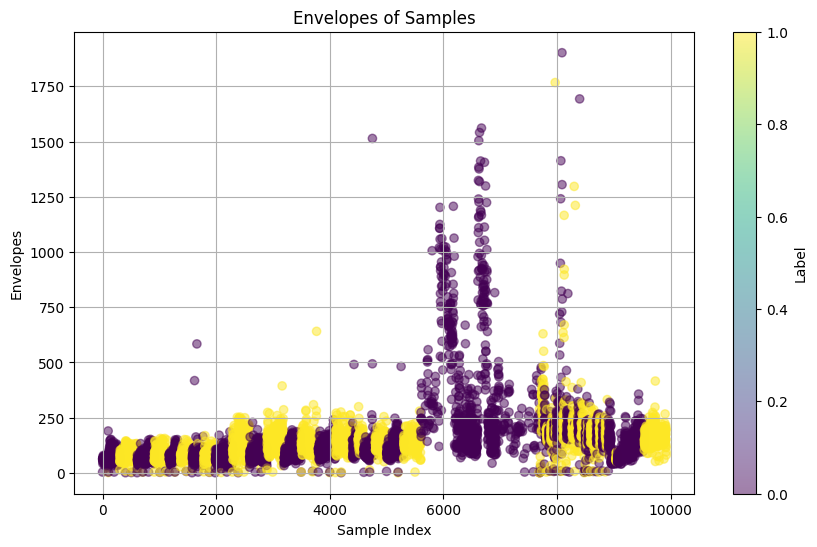

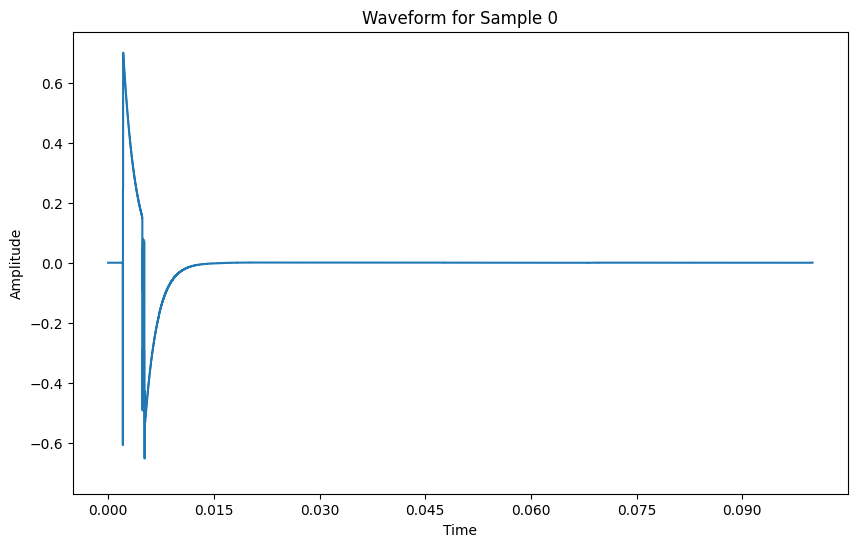

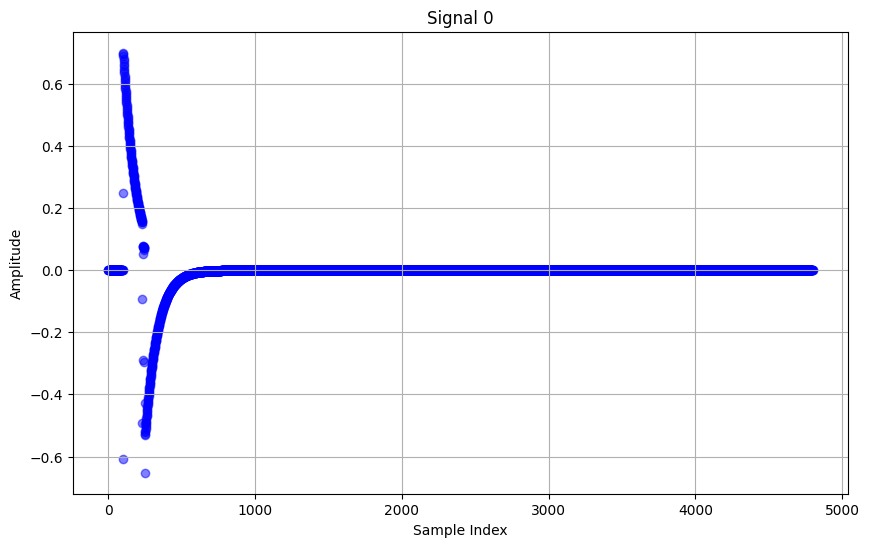

In [48]:
def abs_sum(signal):
    """
    Calculates the sum of absolute values of the audio signal.
    
    Args:
        signal (np.ndarray): The audio signal.
        
    Returns:
        float: The sum of absolute values of the audio signal.
    """
    return np.sum(np.abs(signal))
from numpy.lib.stride_tricks import sliding_window_view

def amplitude_envelope(signal, frame_size=50, hop_length=50):
    """
    signal: 1D np.ndarray of shape (n_samples,)
    frame_size: size of each window (default 50)
    hop_length: step between windows (default 50)
    """
    # get a (n_frames, frame_size) array of all sliding windows
    frames = sliding_window_view(signal, window_shape=frame_size)
    # take every hop_length-th frame (non-overlapping)
    frames = frames[::hop_length]
    # compute the maximum absolute amplitude in each frame
    envelope = np.mean(np.abs(frames), axis=1)
    envelope = np.std(envelope)
    return envelope
def rms_power(signal):
    squared_samples = np.square(signal)
    mean_squared = np.mean(squared_samples)
    rms = np.sqrt(mean_squared)
    return rms

def zero_crossing_count(signal, threshold=0.0001):
    sig = np.where(np.abs(signal)<threshold, 0.0, signal)
    return int(np.sum(sig[:-1] * sig[1:] < 0))

# assuming df has columns [0,1,2,..., T-1, 'y']
envs = df.iloc[:, :-1] \
         .apply(lambda row: zero_crossing_count(row.values), axis=1)

print(np.sum(envs < 10))

print("envs in signal 100: ", envs.iloc[100])
#plot envs vs sample and color using label
plt.figure(figsize=(10, 6))
plt.scatter(envs.index, envs.values, c=df['y'], cmap='viridis', alpha=0.5)
plt.title('Envelopes of Samples')
plt.xlabel('Sample Index')
plt.ylabel('Envelopes')
plt.colorbar(label='Label')
plt.grid(True)
plt.show()

#plot wave 0
plt.figure(figsize=(10, 6))
librosa.display.waveshow(df.iloc[0, :-1].values, sr=48000)
plt.title('Waveform for Sample 0')
plt.xlabel('Time')
plt.ylabel('Amplitude')
plt.show()

#scatter plot for signal 0
plt.figure(figsize=(10, 6))
plt.scatter(range(len(df.iloc[0, :-1].values)), df.iloc[0, :-1].values, color='blue', alpha=0.5)
plt.title('Signal 0')
plt.xlabel('Sample Index')
plt.ylabel('Amplitude')
plt.grid(True)
plt.show()